In [3]:
%%capture
import sys, os
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [4]:
from data_load import boston_dt
from typing import Tuple,List,Dict,Any
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split,KFold
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning
import joblib
import os 
from baseline_data_preparation import X_test,y_test,X_train,y_train,X_val,y_val,preprocessor, X_train_transformed,X_test_transformed,X_val_transformed
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import copy
from catboost import CatBoostRegressor

In [5]:
X_train_transformed.head()


,CRIM_log,ZN_log,NOX_log,DIS_log,LSTAT_log,B_yj,RM,CHAS,RAD_1,RAD_2,RAD_3,RAD_4,RAD_5,RAD_6,RAD_7,RAD_8,RAD_24,ZN_gt0
0,1.751013,0.000000,1.075786,-0.449628,0.614658,-5.175058,0.320244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.847400,0.000000,0.764679,-0.541494,0.771737,-5.175659,-0.362221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.061222,0.000000,-0.282263,0.215372,-0.138998,-0.232581,0.203791,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.113558,0.854876,-0.763695,0.770021,-0.302351,0.230520,-0.469194,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.079271,0.000000,0.393430,-0.402834,0.262997,0.262284,-0.327014,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
436,14.42080,0.0,18.10,0,0.740,6.461,93.3,2.0026,24,666.0,20.2,27.49,18.05
418,73.53410,0.0,18.10,0,0.679,5.957,100.0,1.8026,24,666.0,20.2,16.45,20.62
213,0.14052,0.0,10.59,0,0.489,6.375,32.3,3.9454,4,277.0,18.6,385.81,9.38
67,0.05789,12.5,6.07,0,0.409,5.878,21.4,6.4980,4,345.0,18.9,396.21,8.10
492,0.11132,0.0,27.74,0,0.609,5.983,83.5,2.1099,4,711.0,20.1,396.90,13.35


Feature Importance with naive mlp, Xgboost, Lightgbm and gradient boosting

In [7]:
RANDOM_STATE: int = 42
def compute_feature_importance_naive_mlp(X_train: pd.DataFrame,y_train: pd.Series,X_test: pd.DataFrame,y_test: pd.Series) -> pd.Series:
    mlp = MLPRegressor(hidden_layer_sizes=(50,),max_iter=1000,random_state=RANDOM_STATE)
    mlp.fit(X_train, y_train)
    result = permutation_importance(estimator=mlp,X=X_test,y=y_test,n_repeats=10,scoring="neg_mean_squared_error",random_state=RANDOM_STATE)
    return (pd.Series(result.importances_mean, index=X_train.columns).sort_values(ascending=False))

def compute_feature_importance_xgboost(X_train: pd.DataFrame,y_train: pd.Series) -> pd.Series:
    model = xgb.XGBRegressor(objective="reg:squarederror",n_estimators=300,learning_rate=0.05,random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    
    return (
         pd.Series(model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
    )

def compute_feature_importance_lightgbm(X_train: pd.DataFrame,y_train: pd.Series) -> pd.Series:
    
    model = lgb.LGBMRegressor(
       n_estimators=500,        
       learning_rate=0.05,
       max_depth=-1,            
       min_child_samples=5,    
       min_split_gain=0.0,      
       random_state=RANDOM_STATE,
       force_col_wise=True
    )

    model.fit(X_train, y_train)
    return (
        pd.Series(model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
    )

def compute_feature_importance_gradient_boosting(X_train: pd.DataFrame,y_train: pd.Series) -> pd.Series:
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    return (
        pd.Series(model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
    )


def compare_feature_importances(X_train: pd.DataFrame,y_train: pd.Series,X_test: pd.DataFrame,y_test: pd.Series) -> pd.DataFrame:
    importances: Dict[str, pd.Series] = {
        "MLP_Permutation": compute_feature_importance_naive_mlp(
            X_train, y_train, X_test, y_test
        ),
        "XGBoost": compute_feature_importance_xgboost(X_train, y_train),
        "LightGBM": compute_feature_importance_lightgbm(X_train, y_train),
        "GradientBoosting": compute_feature_importance_gradient_boosting(X_train, y_train),
    }

    return pd.DataFrame(importances)


In [8]:
# Compute and Compare Feature Importances Across All Models
feature_importance_comparison = compare_feature_importances(X_train_transformed, np.log1p(y_train),X_val_transformed,np.log1p(y_val))
print("\n" + "="*80)
print("FEATURE IMPORTANCE COMPARISON ACROSS ALL MODELS")
print("="*80)
print(feature_importance_comparison.round(4))


[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 18
[LightGBM] [Info] Start training from score 3.090337

FEATURE IMPORTANCE COMPARISON ACROSS ALL MODELS
           MLP_Permutation  XGBoost  LightGBM  GradientBoosting
B_yj                0.0351   0.0182      2010            0.0289
CHAS                0.0110   0.0056        58            0.0003
CRIM_log            0.0181   0.0191      2396            0.0549
DIS_log            -0.0120   0.0445      2791            0.0622
LSTAT_log           0.1367   0.4986      2805            0.5828
NOX_log            -0.0117   0.0679      1485            0.0612
RAD_1               0.0289   0.0145        43            0.0012
RAD_2               0.0226   0.0043        57            0.0002
RAD_24              0.4988   0.0676         3            0.0009
RAD_3               0.3184   0.0209        83            0.0009
RAD_4               0.5322   0.0091       127            0.0027
RAD_5 

In [9]:
#a sorted table by mean importance
comparison_with_mean = feature_importance_comparison.copy()
comparison_with_mean['Mean'] = comparison_with_mean.mean(axis=1)
sorted_importances = comparison_with_mean.sort_values('Mean', ascending=False)

print("\n" + "="*80)
print("RANKED BY MEAN IMPORTANCE (Top Features)")
print("="*80)
print(sorted_importances.round(4))


RANKED BY MEAN IMPORTANCE (Top Features)
           MLP_Permutation  XGBoost  LightGBM  GradientBoosting      Mean
LSTAT_log           0.1367   0.4986      2805            0.5828  701.5545
DIS_log            -0.0120   0.0445      2791            0.0622  697.7737
RM                  0.0135   0.1980      2584            0.2004  646.1030
CRIM_log            0.0181   0.0191      2396            0.0549  599.0230
B_yj                0.0351   0.0182      2010            0.0289  502.5205
NOX_log            -0.0117   0.0679      1485            0.0612  371.2794
ZN_log              0.0032   0.0050       320            0.0011   80.0023
RAD_5               0.5078   0.0086       180            0.0018   45.1295
RAD_4               0.5322   0.0091       127            0.0027   31.8860
RAD_3               0.3184   0.0209        83            0.0009   20.8351
CHAS                0.0110   0.0056        58            0.0003   14.5042
RAD_2               0.0226   0.0043        57            0.0002   14.2

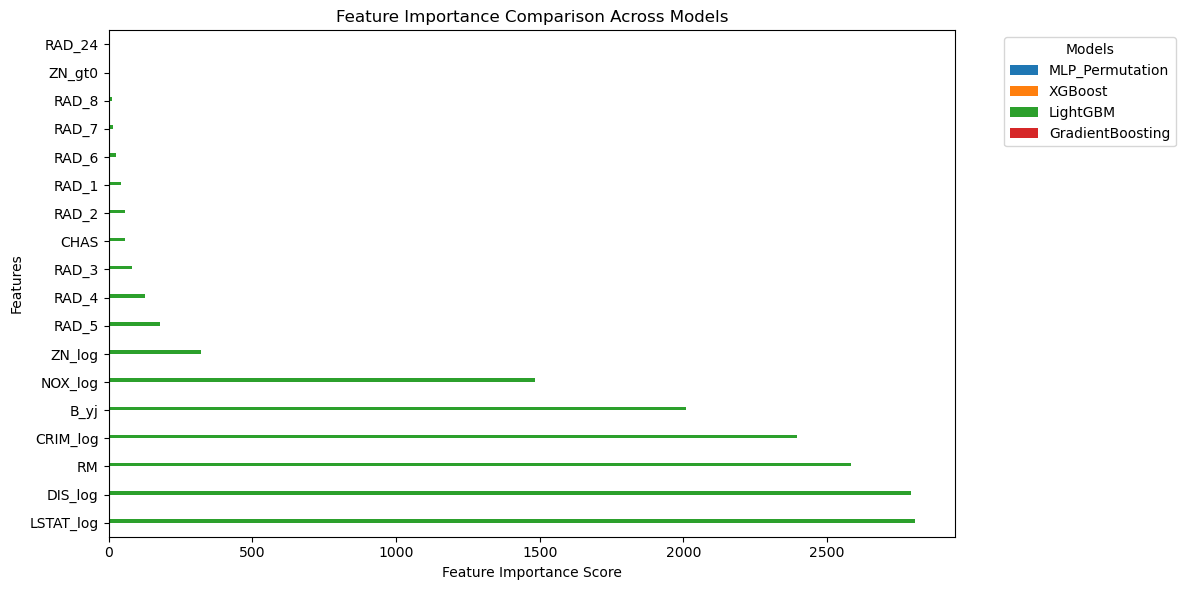

In [10]:

fig, ax = plt.subplots(figsize=(12, 6))
plot_data = sorted_importances.drop('Mean', axis=1)
plot_data.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance Score')
ax.set_ylabel('Features')
ax.set_title('Feature Importance Comparison Across Models')
ax.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
X_val_transformed.drop(columns =['RAD_8', 'RAD_7', 'ZN_gt0', 'RAD_24'])
X_train_transformed.drop(columns =['RAD_8', 'RAD_7', 'ZN_gt0'])
X_test_transformed.drop(columns =['RAD_8', 'RAD_7', 'ZN_gt0'])


,CRIM_log,ZN_log,NOX_log,DIS_log,LSTAT_log,B_yj,RM,CHAS,RAD_1,RAD_2,RAD_3,RAD_4,RAD_5,RAD_6,RAD_24
0,-0.053345,0.000000,-0.101313,-0.517423,-0.382990,0.213787,0.354513,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.075597,1.426821,-0.569161,0.089513,-1.386725,0.306817,0.848375,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.044753,0.000000,0.595820,-0.957445,0.426121,-0.132223,-0.270758,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.053432,0.000000,-0.830187,0.481200,-0.927455,-0.082068,-0.152347,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.109063,0.000000,1.283404,-0.662838,0.372071,-0.437641,0.182671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1.174425,0.000000,0.057476,-0.201703,-0.557877,0.055428,0.836823,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
72,1.662355,0.000000,1.455086,-0.939954,0.756965,-4.555229,-0.457040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
73,-0.044233,1.688426,-0.830187,1.601569,-0.917820,-0.949239,-0.338628,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
74,-0.056269,0.000000,-0.645291,0.094163,-0.237236,-0.325726,-0.044043,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


DeepMLP 

In [12]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Deep MLP Definition 
class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout_prob):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_prob)
        )

    def forward(self, x):
        return x + self.block(x)

class TabularResNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_blocks: int, dropout_prob: float = 0.2):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU()
        )
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout_prob) for _ in range(num_blocks)
        ])
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_layer(x)
        for block in self.blocks:
            x = block(x)
        return self.output_layer(x)

# Training Function 
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3, weight_decay=1e-3, patience=15):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    criterion = nn.MSELoss()
    best_val_mse = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        y_true, y_pred_list = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                pred = model(X_batch).squeeze()
                y_true.extend(y_batch.cpu().numpy())
                y_pred_list.extend(pred.cpu().numpy())

        val_mse = mean_squared_error(y_true, y_pred_list)
        
        # Step Scheduler
        scheduler.step(val_mse)
        
        # Early Stopping
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    if best_model_state:
        model.load_state_dict(best_model_state)
        
    return model, best_val_mse

Hyperparameter Optimization & Train Model

In [13]:
def objective(trial, X, y):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 96)
    num_blocks = trial.suggest_int("num_blocks", 1, 3)
    dropout_prob = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 3e-4, 3e-3, log=True)
    wd = trial.suggest_float("wd", 1e-5, 1e-2, log=True)

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []

    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    y_tensor = torch.tensor(y.values, dtype=torch.float32)

    for train_idx, val_idx in kf.split(X):
        train_ds = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
        val_ds = TensorDataset(X_tensor[val_idx], y_tensor[val_idx])

        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=32)

        # ⭐ FIX 5 APPLIED HERE
        model = TabularResNet(X.shape[1], hidden_dim, num_blocks, dropout_prob).to(DEVICE)

        _, mse = train_model(
            model, train_loader, val_loader,
            epochs=30, lr=lr, weight_decay=wd, patience=5
        )

        fold_scores.append(mse)

    return np.mean(fold_scores)

In [14]:
# Run Hyperparameter Optimization & Train Model
def train_optimized_mlp(X_train, y_train, X_val, y_val, n_trials=20, epochs=150):
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING) # Clean up output

    print("Running Optuna...")
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=n_trials)

    print("Best CV MSE:", study.best_value)
    print("Best Params:", study.best_params)

    best_params = study.best_params
    
    # Train Model
    final_model = TabularResNet(
        input_dim=X_train.shape[1],
        hidden_dim=best_params["hidden_dim"],
        num_blocks=best_params["num_blocks"],
        dropout_prob=best_params["dropout"]
    )
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)

    # Train
    trained_model, val_mse = train_model(
        final_model, train_loader, val_loader,
        epochs=epochs, 
        lr=best_params["lr"], 
        weight_decay=best_params["wd"],
        patience=5
    )

    print("Final validation MSE:", val_mse)
    return trained_model
class MLPWrapper:
       def __init__(self, model, device=DEVICE):
         self.model = model.to(device)
         self.device = device
         self.is_fitted = True

       def predict(self, X, batch_size=256):
         self.model.eval()
         preds = []

         with torch.no_grad():
            for i in range(0, len(X), batch_size):
                batch = X.iloc[i:i+batch_size]
                batch_tensor = torch.tensor(batch.values, dtype=torch.float32).to(self.device)
                out = self.model(batch_tensor).cpu().numpy().flatten()
                preds.append(out)

         return np.concatenate(preds)
# Run
trained_mlp = train_optimized_mlp(X_train_transformed, np.log1p(y_train), X_val_transformed, np.log1p(y_val), n_trials=10, epochs=200)

Running Optuna...
Best CV MSE: 0.05737443788084936
Best Params: {'hidden_dim': 66, 'num_blocks': 1, 'dropout': 0.11006159754140446, 'lr': 0.0018120994028247995, 'wd': 8.443128843491776e-05}
Final validation MSE: 0.0680599534236339


In [15]:
class StackingBlender:
    def __init__(self, base_models: Dict[str, Any], meta_learner: Any, device: str = 'cpu'):
        self.base_models = base_models
        self.meta_learner = meta_learner
        self.device = device
        self.is_fitted = False
        self.model_names = list(self.base_models.keys())
    def fit(self, X_train, y_train, X_val, y_val, verbose=True):

      if verbose:
        print(f"--- Training {len(self.model_names)} Base Models ---")

    # 1. Train ALL base models
      for name in self.model_names:
        model = self.base_models[name]

        if verbose:
            print(f"Training {name}...")

        if name == 'xgb':
            model.set_params(early_stopping_rounds=50)
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        elif name == 'lgb':
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(20, verbose=False)]
            )

        elif name == 'cat':
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False
            )

        elif name == 'mlp':
            continue  # already trained

        else:
            model.fit(X_train, y_train)

    # 2. Generate meta-features
      meta_features = self._get_base_preds(X_val)

      if verbose:
        print("\n" + "="*40)
        print("BASE MODEL VALIDATION SCORES")
        print("="*40)
        for i, name in enumerate(self.model_names):
            score = mean_squared_error(y_val, meta_features[:, i])
            print(f"{name.upper():<10} MSE: {score:.4f}")

      # 3. Train meta-learner 
      if verbose:
        print("\n--- Training Meta Learner ---")

      self.meta_learner.fit(meta_features, y_val)
      self.is_fitted = True

      if verbose:
        stack_pred = self.meta_learner.predict(meta_features)
        stack_score = mean_squared_error(y_val, stack_pred)
        print("-" * 30)
        print(f"STACKED MSE: {stack_score:.4f}")
        print("-" * 30)

        if hasattr(self.meta_learner, 'coef_'):
            print("Model Weights:",
                  dict(zip(self.model_names, self.meta_learner.coef_.flatten())))

 
    def predict(self, X):
        if not self.is_fitted: raise RuntimeError("Model not fitted.")
        meta_features = self._get_base_preds(X)
        return self.meta_learner.predict(meta_features)

    def _get_base_preds(self, X):
        preds_list = []   
        for name in self.model_names:
            model = self.base_models[name]
            p = model.predict(X)  
            preds_list.append(p)
        return np.column_stack(preds_list)


    def save(self, filepath):
      if 'mlp' in self.base_models:
        self.base_models['mlp'].model.to('cpu')

      joblib.dump(self, filepath)
      print(f"Ensemble saved to {filepath}")

      if 'mlp' in self.base_models and self.device != 'cpu':
        self.base_models['mlp'].model.to(self.device)


    @staticmethod
    def load(filepath, device='cpu'):
        obj = joblib.load(filepath)
        obj.device = device
        if 'mlp' in obj.base_models:
           obj.base_models['mlp'].model.to(device)
        return obj
# Main Execution Block
if __name__ == "__main__":
    # Base Models ---
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=6, 
        n_jobs=-1, random_state=42
    )

    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, num_leaves=31, 
        verbose=-1, random_state=42
    )

    cat_model = CatBoostRegressor(
        iterations=1000, learning_rate=0.03, verbose=0, random_seed=42
    )

    ridge_model = Ridge(alpha=0.1 ,positive=True)

    # Dictionary wrapping
    base_models = {
        'xgb': xgb_model,
        'lgb': lgb_model,
        'cat': cat_model,

        'mlp': MLPWrapper(trained_mlp, device=DEVICE) 
    }

    # Initialize & Run ---
    print("Initializing Stacking Blender...")
    stacker = StackingBlender(
        base_models=base_models,
        meta_learner=Ridge(alpha=0.1, positive=True), # The blender model
        device=DEVICE
    )

    # the Validation Report 
    stacker.fit(X_train_transformed, np.log1p(y_train), X_val_transformed, np.log1p(y_val))

Initializing Stacking Blender...
--- Training 4 Base Models ---
Training xgb...
Training lgb...
Training cat...
Training mlp...

BASE MODEL VALIDATION SCORES
XGB        MSE: 0.0359
LGB        MSE: 0.0364
CAT        MSE: 0.0298
MLP        MSE: 0.0681

--- Training Meta Learner ---
------------------------------
STACKED MSE: 0.0267
------------------------------
Model Weights: {'xgb': 0.24955349830283288, 'lgb': 0.011321662787846066, 'cat': 0.5952333922737134, 'mlp': 0.1637214400327528}
